# P1B: CasADi 4D-to-2D Reduced-Order Planner

This notebook uses one authoritative pipeline: 4D local stage cost → minimum 2D projection → projected 2D cost-to-go → policy path extraction.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import casadi as ca
%matplotlib inline


## 2. Configuration

The numerical values below are initial tuning values, not calibrated aircraft-performance parameters.

Vehicle data are registered by model name. The current experiment activates `byu_unicorn_flight_test`, using the Unicorn UAV flight-test polar reported by Ostler et al. (2009): $C_D = 0.0213 - 0.056 C_L + 0.22 C_L^2$. The original `provisional` model remains available for comparison; the BYU powered speed is intentionally retained from the prototype because the cited polar does not calibrate this mission's powered phase.

In [2]:
config = {
    'mission': {'z_start': 0.0, 'h_start': 0.0, 'z_sensor': 2000.0, 'h_sensor': 0.0, 'z_goal': 2500.0, 'h_goal': 0.0},
    'grid': {'z_min': 0.0, 'z_max': 2750.0, 'z_count': 161, 'h_min': 0.0, 'h_max': 200.0, 'h_count': 101},
    'terrain': {'z_ridge': 1250.0, 'h_ridge': 100.0, 'width': 200.0},
    'vehicle': {'mass': 1.5, 'gravity': 9.81, 'air_density': 1.225, 'wing_area': 0.1, 'powered_speed': 21.0, 'v_min': 14.0, 'v_max': 30.0, 'v_count': 5, 'gamma_min_deg': -90.0, 'gamma_max_deg': -1.0, 'gamma_count': 20, 'cd0': 0.025, 'induced_drag_factor': 0.05, 'cl_min': 0.1, 'cl_max': 1.25, 'gamma_feasibility_tolerance_deg': 2.0},
    'detection': {'range_floor': 10.0, 'acoustic_coefficient': 2.4e-3, 'acoustic_speed_exponent': 4, 'radar_coefficient': 5.2e8, 'doppler_coefficient': 1.33e6, 'rcs_min': 0.1, 'rcs_max': 1.0},
    'solver': {'dt_reference': 1.0, 'terrain_clearance': 1.0, 'terrain_numerical_tolerance': 1e-6, 'edge_gamma_tolerance_deg': 7.0, 'max_forward_cells': 3, 'max_descent_cells': 8, 'segment_check_count': 9, 'max_path_steps': 1000, 'convergence_tolerance': 1e-8},
    'weights': {'detection': 1.0, 'time': 0.01},
    'visualization': {'figure_size': (10.0, 6.0), 'cost_colormap': 'viridis'}
}
config['grid']['z'] = np.linspace(config['grid']['z_min'], config['grid']['z_max'], config['grid']['z_count'])
config['grid']['h'] = np.linspace(config['grid']['h_min'], config['grid']['h_max'], config['grid']['h_count'])
config['grid']['v'] = np.linspace(config['vehicle']['v_min'], config['vehicle']['v_max'], config['vehicle']['v_count'])
config['grid']['gamma'] = np.deg2rad(np.linspace(config['vehicle']['gamma_min_deg'], config['vehicle']['gamma_max_deg'], config['vehicle']['gamma_count']))
config['solver']['goal_tolerance_z'] = 1.5 * np.diff(config['grid']['z'])[0]
config['solver']['goal_tolerance_h'] = 1.5 * np.diff(config['grid']['h'])[0]
config['solver']['edge_gamma_tolerance'] = np.deg2rad(config['solver']['edge_gamma_tolerance_deg'])
config['solver']['tangent_tolerance'] = max(config['solver']['goal_tolerance_h'], 0.51 * np.diff(config['grid']['h'])[0])
assert np.isclose(config['vehicle']['gamma_min_deg'], -90.0)
assert np.any(np.isclose(config['grid']['gamma'], -np.pi / 2))

# Vehicle models retain a common interface while allowing aircraft-specific polars.
config['vehicle_models'] = {
    'provisional': {
        **config['vehicle'], 'drag_polar_type': 'quadratic_cl',
        'linear_drag_coefficient': 0.0,
        'quadratic_drag_coefficient': config['vehicle']['induced_drag_factor'],
        'source': 'Initial research-prototype assumption',
    },
    'byu_unicorn_flight_test': {
        'mass': 9.34 / 9.81, 'gravity': 9.81, 'air_density': 1.225,
        'wing_area': 0.321, 'powered_speed': 21.0,
        'v_min': 10.0, 'v_max': 22.6, 'v_count': 5,
        'gamma_min_deg': -90.0, 'gamma_max_deg': -1.0, 'gamma_count': 20,
        'cl_min': 0.05, 'cl_max': 0.50,
        'gamma_feasibility_tolerance_deg': 2.0,
        'drag_polar_type': 'quadratic_cl', 'cd0': 0.0213,
        'linear_drag_coefficient': -0.056,
        'quadratic_drag_coefficient': 0.22,
        'source': 'Ostler et al. 2009 Unicorn flight-test polar; powered speed retained from prototype',
    },
}

def activate_vehicle_model(model_name):
    """Activate one registered vehicle model and rebuild its control grids.

    Parameters
    ----------
    model_name : str
        Key in ``config['vehicle_models']``.

    Returns
    -------
    None
        The active vehicle dictionary and speed/angle grids are updated in ``config``.
    """
    if model_name not in config['vehicle_models']:
        raise KeyError(f'Unknown vehicle model: {model_name}')
    config['active_vehicle_model'] = model_name
    config['vehicle'] = dict(config['vehicle_models'][model_name])
    vehicle = config['vehicle']
    config['grid']['v'] = np.linspace(vehicle['v_min'], vehicle['v_max'], vehicle['v_count'])
    config['grid']['gamma'] = np.deg2rad(np.linspace(vehicle['gamma_min_deg'], vehicle['gamma_max_deg'], vehicle['gamma_count']))

# Run the present experiment with the published Unicorn flight-test polar.
activate_vehicle_model('byu_unicorn_flight_test')
assert config['active_vehicle_model'] == 'byu_unicorn_flight_test'
assert np.isclose(config['vehicle']['cd0'], 0.0213)

# Bellman-over-controls configuration.
config['planner']={'mode':'bellman_over_controls','retain_old_planner_for_comparison':True}
config['weights']['steady_glide_deviation']=0.02
config['vehicle']['gamma_penalty_scale_deg']=10.0
config['solver']['bellman_max_sweeps']=4
config['solver']['bellman_convergence_tolerance']=1e-8

# Switching-candidate mission score: PoD plus normalized glide time.
config['mission_objective']={'w_pod':0.5}; config['mission_objective']['w_t']=1.0-config['mission_objective']['w_pod']; config['mission_objective']['T_reference_s']=np.hypot(config['mission']['z_goal']-config['mission']['z_start'],config['mission']['h_goal']-config['mission']['h_start'])/config['vehicle']['v_max']


## 3. Terrain and LOS Geometry

Terrain is a smooth interpolated Gaussian ridge. The LOS region is the complement of the sensor-side terrain shadow.

In [3]:
terrain_z = config['grid']['z']
terrain_h = config['terrain']['h_ridge'] * np.exp(-0.5 * ((terrain_z - config['terrain']['z_ridge']) / config['terrain']['width']) ** 2)
terrain_interpolant = interpolate.CubicSpline(terrain_z, terrain_h, bc_type='natural')
def terrain(z):
    """Evaluate terrain elevation at one or more range coordinates."""
    return terrain_interpolant(z)
def altitude_above_terrain(z_value, h_value):
    """Return altitude relative to the terrain profile."""
    return np.asarray(h_value) - np.asarray(terrain(z_value))
print('Terrain at launch:', float(terrain(config['mission']['z_start'])))
print('Terrain at goal:', float(terrain(config['mission']['z_goal'])))
def find_tangent():
    """Find the sensor-visible terrain tangent by bisection of slope residual."""
    zs, hs = config['mission']['z_sensor'], config['mission']['h_sensor']
    derivative = terrain_interpolant.derivative(); candidates = terrain_z[terrain_z < zs]
    residual = (terrain(candidates) - hs) / (candidates - zs) - derivative(candidates)
    changes = np.flatnonzero(np.signbit(residual[:-1]) != np.signbit(residual[1:]))
    assert changes.size, 'No LOS tangent found.'
    left, right = candidates[changes[0]], candidates[changes[0] + 1]
    for _ in range(64):
        middle = 0.5 * (left + right)
        if np.signbit((terrain(left)-hs)/(left-zs)-derivative(left)) == np.signbit((terrain(middle)-hs)/(middle-zs)-derivative(middle)): left = middle
        else: right = middle
    zt = 0.5 * (left + right); ht = float(terrain(zt)); slope = (ht-hs)/(zt-zs)
    return zt, ht, slope, hs-slope*zs
tangent_z, tangent_h, tangent_slope, tangent_intercept = find_tangent()
grid_z, grid_h = np.meshgrid(config['grid']['z'], config['grid']['h'], indexing='ij')
occlusion_mask = (grid_z < tangent_z) & (grid_h < tangent_slope * grid_z + tangent_intercept)
los_mask = ~occlusion_mask
def in_los(z, h): return not (z < tangent_z and h < tangent_slope*z + tangent_intercept)


Terrain at launch: 3.293714110306081e-07
Terrain at goal: 3.2931741549820724e-07


## 4. Symbolic Detection and Fixed-Wing State-Cost Model

Radar and radial-velocity outputs are instantaneous rates. `gamma=0` is level flight and `gamma<0` is descent. Acoustic detection is reserved for the powered phase.

In [4]:
z, h, v, gamma = ca.SX.sym('z'), ca.SX.sym('h'), ca.SX.sym('v'), ca.SX.sym('gamma')
p = config['mission']; d = config['detection']; dt = config['solver']['dt_reference']
rng = ca.fmax(ca.sqrt((z-p['z_sensor'])**2 + (h-p['h_sensor'])**2), d['range_floor'])
acoustic_rate = d['acoustic_coefficient'] * v**d['acoustic_speed_exponent'] / rng**2
los_angle = ca.atan2(p['h_sensor']-h, p['z_sensor']-z); aspect = ca.atan2(ca.sin(gamma-los_angle), ca.cos(gamma-los_angle))
rcs = d['rcs_min'] + (d['rcs_max']-d['rcs_min']) * ca.cos(aspect)**2
radar_rate = d['radar_coefficient'] * rcs / rng**4
radial_velocity = v * (ca.cos(gamma)*(p['z_sensor']-z) + ca.sin(gamma)*(p['h_sensor']-h)) / rng
radial_velocity_rate = d['doppler_coefficient'] * radial_velocity**2 / rng**4
glide_rate = radar_rate + radial_velocity_rate
J_symbolic = config['weights']['detection'] * glide_rate * dt + config['weights']['time'] * dt
J4DFunction = ca.Function('J4DFunction', [z,h,v,gamma], [J_symbolic], ['z','h','v','gamma'], ['stage_cost'])
PoweredAcousticRateFunction = ca.Function('PoweredAcousticRateFunction', [z,h,v], [acoustic_rate])
assert isinstance(J4DFunction, ca.Function)
def evaluate_drag_polar(cl, vehicle):
    """Evaluate a registered aircraft drag polar numerically.

    Parameters
    ----------
    cl : float or numpy.ndarray
        Lift coefficient.
    vehicle : dict
        Active vehicle-model parameters.

    Returns
    -------
    float or numpy.ndarray
        Drag coefficient computed as ``cd0 + k1 * cl + k2 * cl**2``.
    """
    if vehicle['drag_polar_type'] != 'quadratic_cl':
        raise ValueError(f"Unsupported drag polar: {vehicle['drag_polar_type']}")
    return (vehicle['cd0'] + vehicle['linear_drag_coefficient'] * cl
            + vehicle['quadratic_drag_coefficient'] * cl**2)


def is_steady_glide_control_feasible(speed, angle, configuration):
    """Test a state/control pair against the active aircraft polar.

    Parameters
    ----------
    speed : float
        Airspeed in metres per second.
    angle : float
        Flight-path angle in radians.
    configuration : dict
        Global configuration containing the active vehicle model.

    Returns
    -------
    bool
        True when lift bounds and steady-glide force balance are satisfied.
    """
    vehicle = configuration['vehicle']
    cl = (2.0 * vehicle['mass'] * vehicle['gravity'] * np.cos(angle)
          / (vehicle['air_density'] * speed**2 * vehicle['wing_area']))
    cd = evaluate_drag_polar(cl, vehicle)
    equilibrium = -np.arctan2(cd, cl)
    tolerance = np.deg2rad(vehicle['gamma_feasibility_tolerance_deg'])
    return bool(vehicle['cl_min'] <= cl <= vehicle['cl_max']
                and cd > 0.0
                and abs(angle - equilibrium) <= tolerance)

assert np.isclose(evaluate_drag_polar(0.0, config['vehicle']), config['vehicle']['cd0'])


# Active implementation: hard bounds plus a soft steady-glide regularizer.
def evaluate_drag_polar(cl, vehicle):
    return (vehicle['cd0'] + vehicle.get('linear_drag_coefficient', 0.0)*cl
            + vehicle.get('quadratic_drag_coefficient', vehicle.get('induced_drag_factor', 0.0))*cl**2)

def is_basic_control_feasible(speed, angle, configuration):
    """Only speed and gamma bounds are hard control constraints."""
    q = configuration['vehicle']
    return bool(q['v_min'] <= speed <= q['v_max']
                and np.deg2rad(q['gamma_min_deg']) <= angle <= np.deg2rad(q['gamma_max_deg']))

def steady_glide_deviation_penalty(speed, angle, configuration):
    q = configuration['vehicle']; eps = 1e-12
    cl = 2*q['mass']*q['gravity']*np.cos(angle)/(q['air_density']*speed**2*q['wing_area'])
    cd = evaluate_drag_polar(cl, q)
    gamma_equilibrium = -np.arctan2(cd, max(cl, eps))
    scale = np.deg2rad(q['gamma_penalty_scale_deg'])
    return configuration['weights']['steady_glide_deviation']*((angle-gamma_equilibrium)/scale)**2

# Compatibility name for the retained sensor-sweep cells.  It intentionally
# no longer enforces steady-glide equilibrium as a hard rejection.
def is_steady_glide_control_feasible(speed, angle, configuration):
    return is_basic_control_feasible(speed, angle, configuration)


## 5. 4D Cost Map

Each finite `J4D(z,h,v,gamma)` is the additive cost accumulated over `dt_reference`; invalid spatial states and infeasible fixed-wing controls are assigned infinity.

In [ ]:
from copy import deepcopy
import time
import warnings

# One evaluation configuration is shared by the snapshot, Stage 12, and Stage 13.
# The attacker planner itself uses mission_objective.w_pod/w_t; the weights below
# only define the defender's outer utility after the common response is solved.
sensor_evaluation_config = {
    'mount_height': 0.0,
    'pod_weight': 0.8,
    'los_area_weight': 0.2,
    'hazard_reference': 1.0,
    'use_diagnostic_hazard_normalization': True,
    'radar_rate_scale': 1.0,
    'radial_velocity_rate_scale': 1.0,
    'acoustic_rate_scale': 1.0,
}
assert np.isclose(sensor_evaluation_config['pod_weight'] + sensor_evaluation_config['los_area_weight'], 1.0)

def make_planner_configuration(base_config, z_count=None, h_count=None):
    """Copy a configuration and rebuild one internally consistent planning grid."""
    local = deepcopy(base_config)
    z_count = int(local['grid']['z_count'] if z_count is None else z_count)
    h_count = int(local['grid']['h_count'] if h_count is None else h_count)
    local['grid']['z_count'], local['grid']['h_count'] = z_count, h_count
    local['grid']['z'] = np.linspace(local['grid']['z_min'], local['grid']['z_max'], z_count)
    local['grid']['h'] = np.linspace(local['grid']['h_min'], local['grid']['h_max'], h_count)
    local['grid']['v'] = np.asarray(base_config['grid']['v'], dtype=float).copy()
    local['grid']['gamma'] = np.asarray(base_config['grid']['gamma'], dtype=float).copy()
    local['solver']['goal_tolerance_z'] = 1.5*np.diff(local['grid']['z'])[0]
    local['solver']['goal_tolerance_h'] = 1.5*np.diff(local['grid']['h'])[0]
    # Tangent tolerance is a physical distance, not a grid-cell count.  Preserve
    # the full-grid snapshot value when changing only the planning resolution.
    local['solver']['tangent_tolerance'] = float(base_config['solver']['tangent_tolerance'])
    return local

def _sensor_rates(z_value, h_value, speed, angle, z_sensor, h_sensor, configuration):
    """The exact radar, Doppler, and acoustic rate formulas used by the snapshot."""
    detection = configuration['detection']
    dz, dh = z_sensor-z_value, h_sensor-h_value
    rng = max(float(np.hypot(dz, dh)), detection['range_floor'])
    los_angle = np.arctan2(dh, dz)
    aspect = np.arctan2(np.sin(angle-los_angle), np.cos(angle-los_angle))
    rcs = detection['rcs_min'] + (detection['rcs_max']-detection['rcs_min'])*np.cos(aspect)**2
    radar = detection['radar_coefficient']*rcs/rng**4
    radial_velocity = speed*(np.cos(angle)*dz + np.sin(angle)*dh)/rng
    doppler = detection['doppler_coefficient']*radial_velocity**2/rng**4
    acoustic = detection['acoustic_coefficient']*speed**detection['acoustic_speed_exponent']/rng**2
    return float(radar), float(doppler), float(acoustic)

def _snapshot_tangent(z_sensor, h_sensor, z_values):
    """Return the terrain upper-envelope tangent seen from the sensor.

    At the fixed (2000, 0) snapshot, changes[0] is the ridge tangent.  When the
    sensor is raised by even millimetres, a non-occluding stationary root can
    appear over the flat left tail.  Selecting the minimum ray slope retains
    the original ridge branch and makes its parameterized continuation physical.
    """
    derivative = terrain_interpolant.derivative()
    candidates = np.asarray(z_values)[np.asarray(z_values) < z_sensor]
    if candidates.size < 2:
        return None, 'no_valid_los_tangent'
    residual = (terrain(candidates)-h_sensor)/(candidates-z_sensor)-derivative(candidates)
    changes = np.flatnonzero(np.signbit(residual[:-1]) != np.signbit(residual[1:]))
    if changes.size == 0:
        return None, 'no_valid_los_tangent'
    root_candidates=[]
    for change in changes:
        left,right=candidates[change],candidates[change+1]
        for _ in range(64):
            middle = 0.5*(left+right)
            f_left = (terrain(left)-h_sensor)/(left-z_sensor)-derivative(left)
            f_middle = (terrain(middle)-h_sensor)/(middle-z_sensor)-derivative(middle)
            if np.signbit(f_left) == np.signbit(f_middle):
                left = middle
            else:
                right = middle
        root_z=0.5*(left+right); root_h=float(terrain(root_z))
        root_slope=float((root_h-h_sensor)/(root_z-z_sensor))
        root_candidates.append((root_slope,float(root_z),root_h))
    slope,tangent_z,tangent_h=min(root_candidates,key=lambda item:item[0])
    return (float(tangent_z), tangent_h, float(slope), float(h_sensor-slope*z_sensor)), None

def _result_without_full_maps(result):
    map_keys = {
        'J4D','StageHazard4D','StagePoD4D','ProjectedCost','ProjectedStagePoD','ProjectedStageJ',
        'LocalMinSpeed','LocalMinGamma','LocalMinSpeedIndex','LocalMinGammaIndex','CostToGo',
        'PoDToGo','TimeToGo','PolicySpeed','PolicyGamma','NextIndexZ','NextIndexH','goal_mask',
        'spatial_invalid_mask','terrain_valid_airspace_mask','los_visible_airspace_mask',
        'los_mask','occlusion_mask','grid_z','grid_h','z_grid','h_grid','v_grid','gamma_grid',
        'switch_records','powered_rejected_coordinates','candidate_coordinates','optimal_switch_record',
    }
    return {key:value for key,value in result.items() if key not in map_keys}

def solve_common_response(z_sensor, h_sensor, planner_config, evaluation_config=None,
                          return_full_maps=False, verbose=False):
    """Run the snapshot planner with only sensor coordinates/grid parameterized.

    This is the sole active LOS, J4D, Bellman, switching, and path implementation
    used by the fixed snapshot and by Stages 12 and 13.
    """
    cfg = deepcopy(planner_config)
    evaluation = sensor_evaluation_config if evaluation_config is None else evaluation_config
    z_sensor, h_sensor = float(z_sensor), float(h_sensor)
    zg, hg = np.asarray(cfg['grid']['z']), np.asarray(cfg['grid']['h'])
    vg, gg = np.asarray(cfg['grid']['v']), np.asarray(cfg['grid']['gamma'])
    cfg['mission']['z_sensor'], cfg['mission']['h_sensor'] = z_sensor, h_sensor
    shape = (zg.size, hg.size)
    tangent, failure = _snapshot_tangent(z_sensor, h_sensor, zg)
    if failure is not None:
        return {'success':False, 'failure_reason':failure, 'z_sensor':z_sensor, 'h_sensor':h_sensor}
    tangent_z, tangent_h, tangent_slope, tangent_intercept = tangent
    mesh_z, mesh_h = np.meshgrid(zg, hg, indexing='ij')
    occlusion = (mesh_z<tangent_z) & (mesh_h<tangent_slope*mesh_z+tangent_intercept)
    los = ~occlusion
    terrain_valid = np.zeros(shape, dtype=bool)
    spatial_invalid = np.zeros(shape, dtype=bool)
    for iz,zv in enumerate(zg):
        for ih,hv in enumerate(hg):
            terrain_valid[iz,ih] = hv >= terrain(zv)+cfg['solver']['terrain_clearance']
            spatial_invalid[iz,ih] = (not terrain_valid[iz,ih]) or (not los[iz,ih])
    los_visible = terrain_valid & los

    array_shape = (zg.size, hg.size, vg.size, gg.size)
    J = np.full(array_shape, np.inf)
    stage_hazard_array = np.full(array_shape, np.inf)
    stage_pod_array = np.full(array_shape, np.inf)
    dt = cfg['solver']['dt_reference']
    for iz,zv in enumerate(zg):
        for ih,hv in enumerate(hg):
            if spatial_invalid[iz,ih]:
                continue
            for iv,speed in enumerate(vg):
                for ig,angle in enumerate(gg):
                    if not is_basic_control_feasible(speed, angle, cfg):
                        continue
                    radar,doppler,_ = _sensor_rates(zv,hv,speed,angle,z_sensor,h_sensor,cfg)
                    stage_hazard = max(0.0, (radar*evaluation['radar_rate_scale'] + doppler*evaluation['radial_velocity_rate_scale'])*dt)
                    stage_pod = 1.0-np.exp(-stage_hazard)
                    stage_hazard_array[iz,ih,iv,ig] = stage_hazard
                    stage_pod_array[iz,ih,iv,ig] = stage_pod
                    J[iz,ih,iv,ig] = (cfg['mission_objective']['w_pod']*stage_pod
                        + cfg['mission_objective']['w_t']*dt/cfg['mission_objective']['T_reference_s'])
    projected = np.min(J, axis=(2,3))
    projected_pod = np.min(stage_pod_array, axis=(2,3))
    projected_stage_j = (cfg['mission_objective']['w_pod']*projected_pod
        + cfg['mission_objective']['w_t']*dt/cfg['mission_objective']['T_reference_s'])
    local_speed = np.full(shape, np.nan); local_gamma = np.full(shape, np.nan)
    local_speed_index = np.full(shape, -1, dtype=int); local_gamma_index = np.full(shape, -1, dtype=int)
    for iz in range(zg.size):
        for ih in range(hg.size):
            if np.isfinite(projected[iz,ih]):
                iv,ig = np.unravel_index(np.argmin(J[iz,ih]), J[iz,ih].shape)
                local_speed[iz,ih], local_gamma[iz,ih] = vg[iv], gg[ig]
                local_speed_index[iz,ih], local_gamma_index[iz,ih] = iv,ig
    if not np.any(np.isfinite(projected)):
        return {'success':False, 'failure_reason':'no_finite_projected_cost', 'z_sensor':z_sensor, 'h_sensor':h_sensor}

    def is_goal(z_value, h_value):
        mission, solver = cfg['mission'], cfg['solver']
        return bool(abs(z_value-mission['z_goal']) <= solver['goal_tolerance_z']
                    and abs(h_value-mission['h_goal']) <= solver['goal_tolerance_h'])

    goal = np.array([[is_goal(zv,hv) for hv in hg] for zv in zg])
    value = np.full(shape, np.inf); policy_speed = np.full(shape, np.nan); policy_gamma = np.full(shape, np.nan)
    next_z = np.full(shape, -1, dtype=int); next_h = np.full(shape, -1, dtype=int)
    value[goal] = 0.0; goal_cells = np.argwhere(goal)

    def transition_ok(z0,h0,z1,h1,speed,angle,terminal=False):
        if not is_basic_control_feasible(speed,angle,cfg) or z1<=z0:
            return False
        fractions = np.linspace(0.0,1.0,cfg['solver']['segment_check_count'])
        for fraction in (fractions[:-1] if terminal else fractions):
            zf,hf = z0+fraction*(z1-z0), h0+fraction*(h1-h0)
            in_los_local = not (zf<tangent_z and hf<tangent_slope*zf+tangent_intercept)
            if hf<terrain(zf)+cfg['solver']['terrain_clearance'] or not in_los_local:
                return False
        return True

    for sweep in range(cfg['solver']['bellman_max_sweeps']):
        before = np.isfinite(value); previous = value.copy()
        for iz in range(zg.size-1,-1,-1):
            for ih in range(hg.size):
                if goal[iz,ih]:
                    continue
                best = value[iz,ih]; data = None
                for iv,speed in enumerate(vg):
                    for ig,angle in enumerate(gg):
                        if not np.isfinite(J[iz,ih,iv,ig]):
                            continue
                        z1 = zg[iz]+speed*dt*np.cos(angle); h1 = hg[ih]+speed*dt*np.sin(angle)
                        terminal = is_goal(z1,h1)
                        if terminal:
                            index = int(np.argmin((zg[goal_cells[:,0]]-z1)**2+(hg[goal_cells[:,1]]-h1)**2))
                            jz,jh = goal_cells[index]; downstream = 0.0
                        else:
                            jz = int(np.searchsorted(zg,z1,side='left')); jh = int(np.argmin(abs(hg-h1)))
                            if jz>=zg.size or jz<=iz or h1<hg[0] or h1>hg[-1] or not np.isfinite(value[jz,jh]):
                                continue
                            downstream = value[jz,jh]
                        if not transition_ok(zg[iz],hg[ih],z1,h1,speed,angle,terminal):
                            continue
                        stage_pod = stage_pod_array[iz,ih,iv,ig]
                        candidate = (cfg['mission_objective']['w_pod']*stage_pod
                            + cfg['mission_objective']['w_t']*dt/cfg['mission_objective']['T_reference_s']
                            + (1.0-stage_pod)*downstream)
                        if candidate<best:
                            best,data = candidate,(speed,angle,int(jz),int(jh))
                if data is not None:
                    value[iz,ih] = best
                    policy_speed[iz,ih],policy_gamma[iz,ih],next_z[iz,ih],next_h[iz,ih] = data
        finite = np.isfinite(value); newly = int(np.count_nonzero(finite & ~before)); common = finite & before
        delta = float(np.max(abs(value[common]-previous[common]))) if np.any(common) else 0.0
        if verbose:
            print(f'Bellman sweep {sweep+1}: newly finite={newly}, max change={delta:.3g}, finite states={finite.sum()}')
        if newly==0 and delta<cfg['solver']['bellman_convergence_tolerance']:
            break
    if not np.any(np.isfinite(value)):
        return {'success':False, 'failure_reason':'no_finite_cost_to_go', 'z_sensor':z_sensor, 'h_sensor':h_sensor}

    pod_to_go = np.full(shape,np.inf); time_to_go = np.full(shape,np.inf)
    pod_to_go[goal] = 0.0; time_to_go[goal] = 0.0
    for iz in range(zg.size-1,-1,-1):
        for ih in range(hg.size):
            if goal[iz,ih] or next_z[iz,ih]<0:
                continue
            jz,jh = next_z[iz,ih],next_h[iz,ih]
            if not (np.isfinite(pod_to_go[jz,jh]) and np.isfinite(time_to_go[jz,jh])):
                continue
            iv = int(np.argmin(abs(vg-policy_speed[iz,ih]))); ig = int(np.argmin(abs(gg-policy_gamma[iz,ih])))
            stage_pod = stage_pod_array[iz,ih,iv,ig]
            pod_to_go[iz,ih] = stage_pod+(1.0-stage_pod)*pod_to_go[jz,jh]
            time_to_go[iz,ih] = dt+(1.0-stage_pod)*time_to_go[jz,jh]

    diagnostics = {'all_z_cells':0,'tangent_in_grid':0,'within_tangent_tolerance':0,
        'finite_projected_cost':0,'finite_cost_to_go':0,'powered_terrain_clear':0,
        'accepted_switch_candidates':0}
    records=[]; powered_rejected=[]; candidate_coordinates=[]
    mission,vehicle,solver = cfg['mission'],cfg['vehicle'],cfg['solver']
    for iz,z_value in enumerate(zg):
        diagnostics['all_z_cells'] += 1
        tangent_height = tangent_slope*z_value+tangent_intercept
        if tangent_height<hg[0] or tangent_height>hg[-1]:
            continue
        diagnostics['tangent_in_grid'] += 1
        # The LOS boundary is represented conservatively by grid cells on or
        # above the continuous tangent.  A below-boundary nearest cell is
        # occluded by construction and caused the former isolated failures.
        vertical_resolution=float(np.diff(hg)[0])
        effective_tolerance=max(float(solver['tangent_tolerance']),vertical_resolution)
        candidate_h_indices=np.flatnonzero((hg>=tangent_height-1e-12)&(hg-tangent_height<=effective_tolerance))
        candidate_h_indices=sorted(candidate_h_indices,key=lambda index:hg[index]-tangent_height)
        for ih in candidate_h_indices:
            tangent_error=abs(hg[ih]-tangent_height)
            diagnostics['within_tangent_tolerance'] += 1
            if not np.isfinite(projected[iz,ih]):
                continue
            diagnostics['finite_projected_cost'] += 1
            if not (np.isfinite(value[iz,ih]) and np.isfinite(pod_to_go[iz,ih]) and np.isfinite(time_to_go[iz,ih])):
                continue
            diagnostics['finite_cost_to_go'] += 1; candidate_coordinates.append((zg[iz],hg[ih]))
            z_switch,h_switch = zg[iz],hg[ih]
            powered_distance = np.hypot(z_switch-mission['z_start'],h_switch-mission['h_start'])
            if powered_distance<=0:
                continue
            powered_time = powered_distance/vehicle['powered_speed']
            fractions = np.linspace(0,1,max(solver['segment_check_count'],25))
            powered_z = mission['z_start']+fractions*(z_switch-mission['z_start'])
            powered_h = mission['h_start']+fractions*(h_switch-mission['h_start'])
            margins = altitude_above_terrain(powered_z,powered_h)
            if np.any(margins[1:-1] < -solver['terrain_numerical_tolerance']) or margins[-1] < -solver['terrain_numerical_tolerance']:
                powered_rejected.append((z_switch,h_switch)); continue
            acoustic_rates = np.array([_sensor_rates(zv,hv,vehicle['powered_speed'],0.0,z_sensor,h_sensor,cfg)[2]
                                       * evaluation['acoustic_rate_scale'] for zv,hv in zip(powered_z,powered_h)])
            powered_hazard = float(np.trapezoid(acoustic_rates,fractions*powered_time))
            powered_pod = 1.0-np.exp(-powered_hazard)
            glide_pod = float(pod_to_go[iz,ih]); glide_time = float(time_to_go[iz,ih])
            reference_time = cfg['mission_objective']['T_reference_s']
            mission_pod = 1.0-(1.0-powered_pod)*(1.0-glide_pod)
            score = (cfg['mission_objective']['w_pod']*powered_pod
                + cfg['mission_objective']['w_t']*powered_time/reference_time
                + (1.0-powered_pod)*value[iz,ih])
            diagnostics['powered_terrain_clear'] += 1; diagnostics['accepted_switch_candidates'] += 1
            records.append({'switch_iz':int(iz),'switch_ih':int(ih),'z_switch':float(z_switch),'h_switch':float(h_switch),
                'powered_distance':float(powered_distance),'powered_time':float(powered_time),'powered_hazard':powered_hazard,
                'powered_pod':float(powered_pod),'glide_pod':glide_pod,'mission_pod':float(mission_pod),
                'glide_time':glide_time,'global_reference_time':float(reference_time),'normalized_glide_time':float(glide_time/reference_time),
                'powered_cost':float(powered_pod),'glide_cost_to_go':float(value[iz,ih]),'total_mission_cost':float(score),
                'tangent_height':float(tangent_height),'tangent_grid_error':float(tangent_error)})
    if not records:
        failure_map=[('tangent_in_grid','no_tangent_cells_inside_grid'),('within_tangent_tolerance','no_cells_within_tangent_tolerance'),
            ('finite_projected_cost','no_finite_projected_cost_on_tangent'),('finite_cost_to_go','no_finite_cost_to_go_on_tangent'),
            ('powered_terrain_clear','all_powered_segments_intersect_terrain')]
        reason=next((label for key,label in failure_map if diagnostics[key]==0),'no_valid_switching_candidate')
        return {'success':False,'failure_reason':reason,'z_sensor':z_sensor,'h_sensor':h_sensor,
                'switch_diagnostics':diagnostics,'finite_projected_count':int(np.isfinite(projected).sum()),
                'finite_cost_to_go_count':int(np.isfinite(value).sum())}
    records.sort(key=lambda item:item['total_mission_cost']); best = records[0]
    iz,ih = best['switch_iz'],best['switch_ih']; indices=[]; visited=set()
    for _ in range(solver['max_path_steps']):
        indices.append((iz,ih))
        if goal[iz,ih]:
            break
        if (iz,ih) in visited or next_z[iz,ih]<0:
            return {'success':False,'failure_reason':'path_extraction_failed','z_sensor':z_sensor,'h_sensor':h_sensor,
                    'switch_diagnostics':diagnostics}
        visited.add((iz,ih)); jz,jh=next_z[iz,ih],next_h[iz,ih]
        if jz<=iz or not np.isfinite(value[jz,jh]):
            return {'success':False,'failure_reason':'nonforward_or_invalid_policy','z_sensor':z_sensor,'h_sensor':h_sensor,
                    'switch_diagnostics':diagnostics}
        iz,ih=jz,jh
    else:
        return {'success':False,'failure_reason':'maximum_path_steps_exceeded','z_sensor':z_sensor,'h_sensor':h_sensor,
                'switch_diagnostics':diagnostics}
    glide_path = np.array([(zg[i],hg[j]) for i,j in indices])
    powered_path = np.array([(mission['z_start'],mission['h_start']),(best['z_switch'],best['h_switch'])])

    glide_radar=0.0; glide_doppler=0.0; physical_glide_time=0.0
    for (iz,ih),(jz,jh) in zip(indices[:-1],indices[1:]):
        edge_time=np.hypot(zg[jz]-zg[iz],hg[jh]-hg[ih])/policy_speed[iz,ih]
        radar,doppler,_=_sensor_rates(zg[iz],hg[ih],policy_speed[iz,ih],policy_gamma[iz,ih],z_sensor,h_sensor,cfg)
        glide_radar += radar*evaluation['radar_rate_scale']*edge_time
        glide_doppler += doppler*evaluation['radial_velocity_rate_scale']*edge_time
        physical_glide_time += edge_time
    mission_hazard=best['powered_hazard']+glide_radar+glide_doppler
    physical_mission_pod=1.0-np.exp(-mission_hazard)
    dz=float(np.diff(zg)[0]); dh=float(np.diff(hg)[0]); cell_area=dz*dh
    admissible_area=float(np.count_nonzero(terrain_valid)*cell_area)
    los_area=float(np.count_nonzero(los_visible)*cell_area)
    normalized_los=float(np.clip(los_area/admissible_area,0.0,1.0))
    detection_score=(mission_hazard/(mission_hazard+evaluation['hazard_reference'])
        if evaluation['use_diagnostic_hazard_normalization'] else physical_mission_pod)
    defender_utility=float(evaluation['pod_weight']*detection_score+evaluation['los_area_weight']*normalized_los)
    result={'success':True,'failure_reason':None,'z_sensor':z_sensor,'h_sensor':h_sensor,
        'tangent_z':tangent_z,'tangent_h':tangent_h,'tangent_slope':tangent_slope,'tangent_intercept':tangent_intercept,
        'attacker_total_cost':float(best['total_mission_cost']),'attacker_powered_cost':float(best['powered_pod']),
        'attacker_glide_cost':float(best['glide_cost_to_go']),'switch_z':float(best['z_switch']),'switch_h':float(best['h_switch']),
        'policy_mission_pod':float(best['mission_pod']),'mission_detection_hazard':float(mission_hazard),
        'mission_pod':float(physical_mission_pod),'normalized_detection_score':float(detection_score),
        'powered_acoustic_hazard':float(best['powered_hazard']),'glide_radar_hazard':float(glide_radar),
        'glide_radial_velocity_hazard':float(glide_doppler),'glide_detection_hazard':float(glide_radar+glide_doppler),
        'powered_time':float(best['powered_time']),'glide_time':float(best['glide_time']),
        'physical_glide_time':float(physical_glide_time),
        'total_time':float(best['powered_time']+(1.0-best['powered_pod'])*best['glide_time']),
        'powered_path_length':float(best['powered_distance']),
        'glide_path_length':float(np.sum(np.hypot(np.diff(glide_path[:,0]),np.diff(glide_path[:,1])))),
        'total_path_length':float(best['powered_distance']+np.sum(np.hypot(np.diff(glide_path[:,0]),np.diff(glide_path[:,1])))),
        'powered_path':powered_path,'glide_path':glide_path,'defender_utility':defender_utility,
        'admissible_airspace_area':admissible_area,'los_area':los_area,'normalized_los_area':normalized_los,
        'switch_diagnostics':diagnostics,'finite_projected_count':int(np.isfinite(projected).sum()),
        'finite_cost_to_go_count':int(np.isfinite(value).sum()),
        'tangent_band_candidate_count':diagnostics['within_tangent_tolerance'],
        'finite_projected_on_tangent':diagnostics['finite_projected_cost'],
        'finite_cost_to_go_on_tangent':diagnostics['finite_cost_to_go'],
        'powered_clear_candidate_count':diagnostics['powered_terrain_clear']}
    full_maps={'J4D':J,'StageHazard4D':stage_hazard_array,'StagePoD4D':stage_pod_array,
        'ProjectedCost':projected,'ProjectedStagePoD':projected_pod,'ProjectedStageJ':projected_stage_j,
        'LocalMinSpeed':local_speed,'LocalMinGamma':local_gamma,'LocalMinSpeedIndex':local_speed_index,
        'LocalMinGammaIndex':local_gamma_index,'CostToGo':value,'PoDToGo':pod_to_go,'TimeToGo':time_to_go,
        'PolicySpeed':policy_speed,'PolicyGamma':policy_gamma,'NextIndexZ':next_z,'NextIndexH':next_h,
        'goal_mask':goal,'spatial_invalid_mask':spatial_invalid,'terrain_valid_airspace_mask':terrain_valid,
        'los_visible_airspace_mask':los_visible,'los_mask':los,'occlusion_mask':occlusion,
        'grid_z':mesh_z,'grid_h':mesh_h,'z_grid':zg,'h_grid':hg,'v_grid':vg,'gamma_grid':gg,
        'switch_records':records,'powered_rejected_coordinates':powered_rejected,
        'candidate_coordinates':candidate_coordinates,'optimal_switch_record':best}
    result.update(full_maps)
    if verbose:
        print(f'Sensor ({z_sensor:.1f}, {h_sensor:.3f}): Bellman finite states={np.isfinite(value).sum()}, '
              f'accepted switches={diagnostics["accepted_switch_candidates"]}, J={best["total_mission_cost"]:.6g}')
    return result if return_full_maps else _result_without_full_maps(result)

common_response_cache = {}
def solve_attacker_response_for_sensor(z_sensor, planner_config, evaluation_config=None,
                                       h_sensor_override=None, return_full_maps=False,
                                       use_cache=True, verbose=False):
    """Thin coordinate wrapper around solve_common_response; contains no planner logic."""
    evaluation = sensor_evaluation_config if evaluation_config is None else evaluation_config
    h_sensor = (float(terrain(z_sensor)+evaluation['mount_height'])
                if h_sensor_override is None else float(h_sensor_override))
    key=(round(float(z_sensor),10),round(h_sensor,10),len(planner_config['grid']['z']),len(planner_config['grid']['h']),
         float(planner_config['grid']['z'][0]),float(planner_config['grid']['z'][-1]),
         float(planner_config['grid']['h'][0]),float(planner_config['grid']['h'][-1]))
    if use_cache and not return_full_maps and key in common_response_cache:
        return deepcopy(common_response_cache[key])
    result=solve_common_response(z_sensor,h_sensor,planner_config,evaluation,return_full_maps=return_full_maps,verbose=verbose)
    if use_cache and not return_full_maps:
        common_response_cache[key]=deepcopy(result)
    return result

# The fixed snapshot now calls the same common solver used by Stages 12 and 13.
snapshot_planner_config = make_planner_configuration(config)
snapshot_result = solve_common_response(config['mission']['z_sensor'],config['mission']['h_sensor'],
    snapshot_planner_config,sensor_evaluation_config,return_full_maps=True,verbose=True)
assert snapshot_result['success'], snapshot_result

z_grid,h_grid,v_grid,gamma_grid=(snapshot_result[key] for key in ('z_grid','h_grid','v_grid','gamma_grid'))
grid_z,grid_h=snapshot_result['grid_z'],snapshot_result['grid_h']
tangent_z,tangent_h=snapshot_result['tangent_z'],snapshot_result['tangent_h']
tangent_slope,tangent_intercept=snapshot_result['tangent_slope'],snapshot_result['tangent_intercept']
los_mask,occlusion_mask=snapshot_result['los_mask'],snapshot_result['occlusion_mask']
spatial_invalid_mask=snapshot_result['spatial_invalid_mask']
J4D,StageHazard4D,StagePoD4D=(snapshot_result[key] for key in ('J4D','StageHazard4D','StagePoD4D'))
ProjectedCost,ProjectedStagePoD,ProjectedStageJ=(snapshot_result[key] for key in ('ProjectedCost','ProjectedStagePoD','ProjectedStageJ'))
LocalMinSpeed,LocalMinGamma=snapshot_result['LocalMinSpeed'],snapshot_result['LocalMinGamma']
LocalMinSpeedIndex,LocalMinGammaIndex=snapshot_result['LocalMinSpeedIndex'],snapshot_result['LocalMinGammaIndex']
ProjectedOptimalSpeed,ProjectedOptimalGamma=LocalMinSpeed,LocalMinGamma
ProjectedOptimalSpeedIndex,ProjectedOptimalGammaIndex=LocalMinSpeedIndex,LocalMinGammaIndex
CostToGo,PoDToGo,TimeToGo=(snapshot_result[key] for key in ('CostToGo','PoDToGo','TimeToGo'))
PolicySpeed,PolicyGamma=snapshot_result['PolicySpeed'],snapshot_result['PolicyGamma']
NextIndexZ,NextIndexH=snapshot_result['NextIndexZ'],snapshot_result['NextIndexH']
PolicyNextIndexZ,PolicyNextIndexH=NextIndexZ,NextIndexH
goal_mask=snapshot_result['goal_mask']
switch_records=snapshot_result['switch_records']; candidate_diagnostics=snapshot_result['switch_diagnostics']
powered_rejected_coordinates=snapshot_result['powered_rejected_coordinates']
candidate_coordinates=snapshot_result['candidate_coordinates']; optimal_switch_record=snapshot_result['optimal_switch_record']
optimal_glide_path=snapshot_result['glide_path']; powered_path=snapshot_result['powered_path']
finite_gamma_counts=np.sum(np.isfinite(J4D),axis=(0,1,2))
print('gamma degree | finite J4D cell count')
for angle,count in zip(np.rad2deg(gamma_grid),finite_gamma_counts): print(f'{angle:11.2f} | {count}')


## 6. 4D-to-2D Minimum-Cost Projection

`ProjectedCost` is exactly the local minimum of `J4D` over speed and glide angle. Its control maps are local minimizers, not automatically a global path policy.

In [ ]:
# The 4D projection is produced by solve_common_response.  This cell retains the
# original section boundary and validates the shared snapshot result.
assert ProjectedCost.shape == (z_grid.size,h_grid.size)
finite_projection=np.argwhere(np.isfinite(ProjectedCost)); assert finite_projection.size
riz,rih=finite_projection[0]
assert np.isclose(ProjectedCost[riz,rih],np.min(J4D[riz,rih][np.isfinite(J4D[riz,rih])]))
assert np.allclose(ProjectedStageJ[np.isfinite(ProjectedStageJ)],ProjectedCost[np.isfinite(ProjectedCost)])


## 7. 2D Projected Cost-to-Go

The projected grid planner uses only terrain/LOS-valid forward and descending stencil edges. Edge cost scales the finite-interval projected stage cost by actual edge time divided by `dt_reference`.

In [ ]:
# LEGACY (preserved, not executed): original projected-policy implementation
# def is_goal_region(zv, hv, configuration):
#     """Terminal landing set; unlike airborne states, it is terrain-clearance exempt."""
#     m, s = configuration['mission'], configuration['solver']; return bool(abs(zv-m['z_goal']) <= s['goal_tolerance_z'] and abs(hv-m['h_goal']) <= s['goal_tolerance_h'])
# goal_mask = np.zeros(ProjectedCost.shape, dtype=bool)
# for iz, zv in enumerate(z_grid):
#     for ih, hv in enumerate(h_grid): goal_mask[iz, ih] = is_goal_region(zv, hv, config)
# assert np.any(goal_mask), 'No grid cells belong to the terminal goal region.'
# def edge_feasible(iz, ih, jz, jh):
#     """Validate one projected-grid forward glide edge, including its segment."""
#     zv,hv,znext,hnext = z_grid[iz],h_grid[ih],z_grid[jz],h_grid[jh]; dz,dh = znext-zv,hnext-hv
#     if dz < 0 or (dz == 0 and dh == 0) or dh > 0 or not np.isfinite(ProjectedOptimalSpeed[iz,ih]): return False
#     angle = np.arctan2(dh,dz); q=config['vehicle']; s=config['solver']
#     if not (np.deg2rad(q['gamma_min_deg']) <= angle <= np.deg2rad(q['gamma_max_deg']) and abs(angle-ProjectedOptimalGamma[iz,ih]) <= s['edge_gamma_tolerance']): return False
#     fractions=np.linspace(0.0,1.0,s['segment_check_count']); terminal=goal_mask[jz,jh]
#     for fraction in (fractions[:-1] if terminal else fractions):
#         zs,hs=zv+fraction*dz,hv+fraction*dh
#         if hs < terrain(zs)+s['terrain_clearance'] or not in_los(zs,hs): return False
#     return True
# CostToGo=np.full(ProjectedCost.shape,np.inf); NextIndexZ=np.full(ProjectedCost.shape,-1,dtype=int); NextIndexH=np.full(ProjectedCost.shape,-1,dtype=int); CostToGo[goal_mask]=0.0
# for _ in range(z_grid.size):
#     finite_before=np.isfinite(CostToGo); previous=CostToGo.copy()
#     for iz in range(z_grid.size-1,-1,-1):
#         for ih in range(h_grid.size):
#             if goal_mask[iz,ih] or not np.isfinite(ProjectedCost[iz,ih]): continue
#             candidates=[]
#             for dz_index in range(0,config['solver']['max_forward_cells']+1):
#                 for dh_index in range(-config['solver']['max_descent_cells'],1):
#                     jz,jh=iz+dz_index,ih+dh_index
#                     if jz>=z_grid.size or jh<0 or not np.isfinite(CostToGo[jz,jh]) or not edge_feasible(iz,ih,jz,jh): continue
#                     edge_time=np.hypot(z_grid[jz]-z_grid[iz],h_grid[jh]-h_grid[ih])/ProjectedOptimalSpeed[iz,ih]
#                     candidates.append((ProjectedCost[iz,ih]*edge_time/config['solver']['dt_reference']+CostToGo[jz,jh],jz,jh))
#             if candidates:
#                 best=min(candidates,key=lambda item:item[0]); CostToGo[iz,ih],NextIndexZ[iz,ih],NextIndexH[iz,ih]=best
#     finite_after=np.isfinite(CostToGo); newly_finite=np.count_nonzero(finite_after & ~finite_before); common=finite_after & finite_before
#     max_change=np.max(np.abs(CostToGo[common]-previous[common])) if np.any(common) else 0.0
#     if newly_finite==0 and max_change < config['solver']['convergence_tolerance']: break
# assert np.any(np.isfinite(CostToGo)); print('Goal cells:',goal_mask.sum(),'Finite projected-cost cells:',np.isfinite(ProjectedCost).sum(),'Finite cost-to-go cells:',np.isfinite(CostToGo).sum())


# DEPRECATED: the former cell-local Bellman implementation was removed.
# Active CostToGo/policy maps are generated inside solve_common_response so the
# snapshot and all sensor-location evaluations execute exactly one implementation.
def is_goal_region(zv,hv,configuration):
    mission,solver=configuration['mission'],configuration['solver']
    return bool(abs(zv-mission['z_goal'])<=solver['goal_tolerance_z'] and abs(hv-mission['h_goal'])<=solver['goal_tolerance_h'])
assert np.any(goal_mask) and np.any(np.isfinite(CostToGo))
assert np.all((PoDToGo[np.isfinite(PoDToGo)]>=0.0)&(PoDToGo[np.isfinite(PoDToGo)]<=1.0))
print('Goal cells:',goal_mask.sum(),'Finite J4D cells:',np.isfinite(ProjectedCost).sum(),
      'Finite Bellman value cells:',np.isfinite(CostToGo).sum())

# DEPRECATED: the former cell-local Bellman implementation was removed.
# Active CostToGo/policy maps are generated inside solve_common_response so the
# snapshot and all sensor-location evaluations execute exactly one implementation.
def is_goal_region(zv,hv,configuration):
    mission,solver=configuration['mission'],configuration['solver']
    return bool(abs(zv-mission['z_goal'])<=solver['goal_tolerance_z'] and abs(hv-mission['h_goal'])<=solver['goal_tolerance_h'])
assert np.any(goal_mask) and np.any(np.isfinite(CostToGo))
assert np.all((PoDToGo[np.isfinite(PoDToGo)]>=0.0)&(PoDToGo[np.isfinite(PoDToGo)]<=1.0))
print('Goal cells:',goal_mask.sum(),'Finite J4D cells:',np.isfinite(ProjectedCost).sum(),
      'Finite Bellman value cells:',np.isfinite(CostToGo).sum())

# DEPRECATED: the former cell-local Bellman implementation was removed.
# Active CostToGo/policy maps are generated inside solve_common_response so the
# snapshot and all sensor-location evaluations execute exactly one implementation.
def is_goal_region(zv,hv,configuration):
    mission,solver=configuration['mission'],configuration['solver']
    return bool(abs(zv-mission['z_goal'])<=solver['goal_tolerance_z'] and abs(hv-mission['h_goal'])<=solver['goal_tolerance_h'])
assert np.any(goal_mask) and np.any(np.isfinite(CostToGo))
assert np.all((PoDToGo[np.isfinite(PoDToGo)]>=0.0)&(PoDToGo[np.isfinite(PoDToGo)]<=1.0))
print('Goal cells:',goal_mask.sum(),'Finite J4D cells:',np.isfinite(ProjectedCost).sum(),
      'Finite Bellman value cells:',np.isfinite(CostToGo).sum())

# DEPRECATED: the former cell-local Bellman implementation was removed.
# Active CostToGo/policy maps are generated inside solve_common_response so the
# snapshot and all sensor-location evaluations execute exactly one implementation.
def is_goal_region(zv,hv,configuration):
    mission,solver=configuration['mission'],configuration['solver']
    return bool(abs(zv-mission['z_goal'])<=solver['goal_tolerance_z'] and abs(hv-mission['h_goal'])<=solver['goal_tolerance_h'])
assert np.any(goal_mask) and np.any(np.isfinite(CostToGo))
assert np.all((PoDToGo[np.isfinite(PoDToGo)]>=0.0)&(PoDToGo[np.isfinite(PoDToGo)]<=1.0))
print('Goal cells:',goal_mask.sum(),'Finite J4D cells:',np.isfinite(ProjectedCost).sum(),
      'Finite Bellman value cells:',np.isfinite(CostToGo).sum())

# DEPRECATED: the former cell-local Bellman implementation was removed.
# Active CostToGo/policy maps are generated inside solve_common_response so the
# snapshot and all sensor-location evaluations execute exactly one implementation.
def is_goal_region(zv,hv,configuration):
    mission,solver=configuration['mission'],configuration['solver']
    return bool(abs(zv-mission['z_goal'])<=solver['goal_tolerance_z'] and abs(hv-mission['h_goal'])<=solver['goal_tolerance_h'])
assert np.any(goal_mask) and np.any(np.isfinite(CostToGo))
assert np.all((PoDToGo[np.isfinite(PoDToGo)]>=0.0)&(PoDToGo[np.isfinite(PoDToGo)]<=1.0))
print('Goal cells:',goal_mask.sum(),'Finite J4D cells:',np.isfinite(ProjectedCost).sum(),
      'Finite Bellman value cells:',np.isfinite(CostToGo).sum())


## 8. Switching-Point Evaluation and Projected-Policy Path Extraction

In [ ]:
# DEPRECATED: the former cell-local powered_record/switching/path implementation
# was removed.  The values below come from the same common solver result.
print('Switching candidate diagnostics:')
for key,value in candidate_diagnostics.items(): print(f'  {key}: {value}')
print('Five best switching candidates:')
for record in switch_records[:5]: print(record)
assert np.isfinite(optimal_switch_record['total_mission_cost'])
figure,axis=plt.subplots(figsize=config['visualization']['figure_size'])
axis.plot(terrain_z,terrain_h,color='black',label='Terrain')
axis.plot(z_grid,tangent_slope*z_grid+tangent_intercept,'k--',label='LOS tangent')
if powered_rejected_coordinates:
    axis.scatter(*np.asarray(powered_rejected_coordinates).T,color='gray',label='Powered terrain rejected')
if switch_records:
    accepted=np.array([(record['z_switch'],record['h_switch']) for record in switch_records])
    axis.scatter(accepted[:,0],accepted[:,1],color='blue',label='Accepted switching candidate')
    for record in switch_records:
        axis.plot([config['mission']['z_start'],record['z_switch']],
                  [config['mission']['h_start'],record['h_switch']],color='blue',alpha=0.12)
axis.plot(config['mission']['z_start'],config['mission']['h_start'],'ko',label='Launch')
axis.plot(config['mission']['z_sensor'],config['mission']['h_sensor'],'k^',label='Sensor')
axis.plot(config['mission']['z_goal'],config['mission']['h_goal'],'y*',label='Goal')
axis.set(xlabel='Range z (m)',ylabel='Height h (m)',ylim=(config['grid']['h_min'],config['grid']['h_max']))
axis.legend(); axis.set_title('Powered switching-candidate terrain diagnostic'); figure.tight_layout(); plt.show()
assert np.all(np.diff(optimal_glide_path[:,0])>0)
assert np.all(np.diff(optimal_glide_path[:,1])<=config['solver']['convergence_tolerance'])


## 9. Validation and Final Visualization

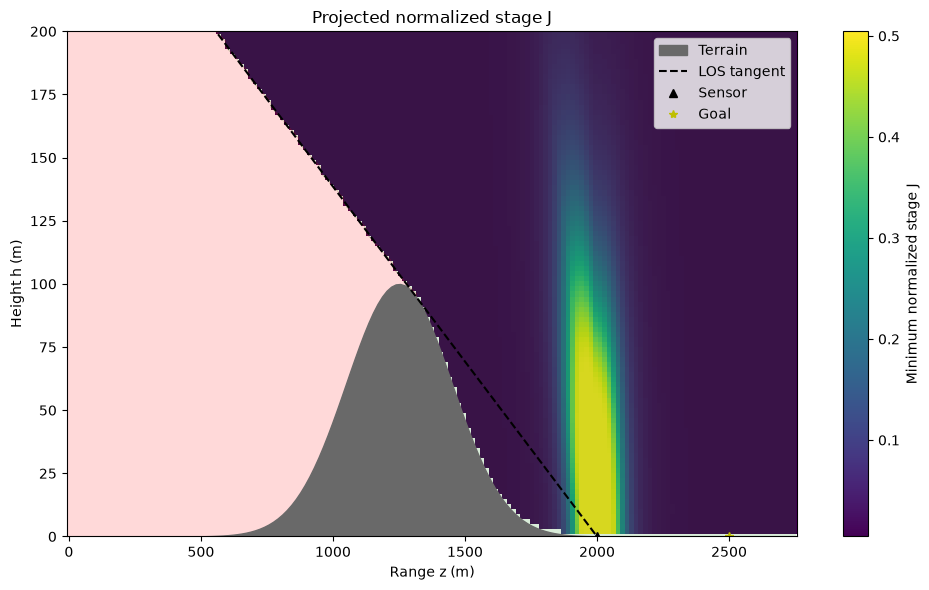

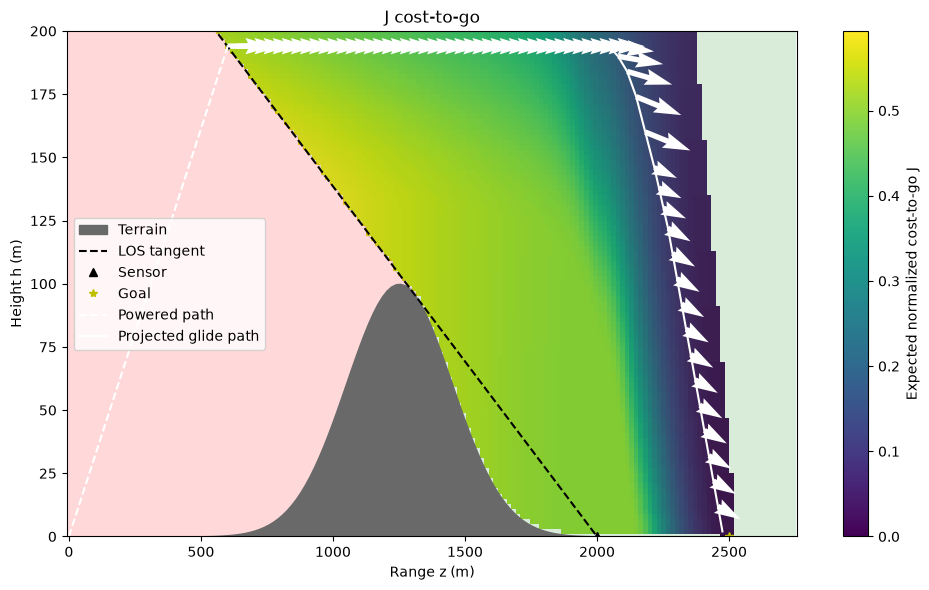

In [9]:
def overlay(axis):
    axis.contourf(grid_z,grid_h,occlusion_mask.astype(int),levels=[-.5,.5,1.5],colors=['green','red'],alpha=.15); axis.fill_between(terrain_z,terrain_h,color='dimgray',label='Terrain'); axis.plot(z_grid,tangent_slope*z_grid+tangent_intercept,'k--',label='LOS tangent'); axis.plot(p['z_sensor'],p['h_sensor'],'k^',label='Sensor'); axis.plot(p['z_goal'],p['h_goal'],'y*',label='Goal'); axis.set(xlabel='Range z (m)',ylabel='Height h (m)',ylim=(config['grid']['h_min'],config['grid']['h_max']))
for values,title,label,path in [(ProjectedStageJ,'Projected normalized stage J','Minimum normalized stage J',False),(CostToGo,'J cost-to-go','Expected normalized cost-to-go J',True)]:
    fig,ax=plt.subplots(figsize=config['visualization']['figure_size']); image=ax.pcolormesh(z_grid,h_grid,np.ma.masked_invalid(values).T,shading='auto',cmap=config['visualization']['cost_colormap']); overlay(ax)
    if path: ax.plot(powered_path[:,0],powered_path[:,1],'w--',label='Powered path'); ax.plot(optimal_glide_path[:,0],optimal_glide_path[:,1],'w-',label='Projected glide path'); dpath=np.diff(optimal_glide_path,axis=0); ax.quiver(optimal_glide_path[:-1,0],optimal_glide_path[:-1,1],dpath[:,0],dpath[:,1],color='white')
    ax.set_title(title); ax.legend(); fig.colorbar(image,ax=ax,label=label); fig.tight_layout()
plt.show()


## 10. Reduced-Order Approximation Summary

This notebook uses a reduced-order planning approximation: 4D local stage-cost evaluation → minimum-cost projection over speed and glide angle → 2D projected cost-to-go propagation → projected-policy path extraction. Because speed and glide angle are minimized locally before Bellman propagation, this is not mathematically equivalent to full 4D dynamic programming. It is retained as the intended reduced-order approximation.

## 11. Final Projected Cost-to-Go Mission Plot

The heatmap is the numerical projected 2D cost-to-go map produced from the symbolic 4D local stage-cost model.

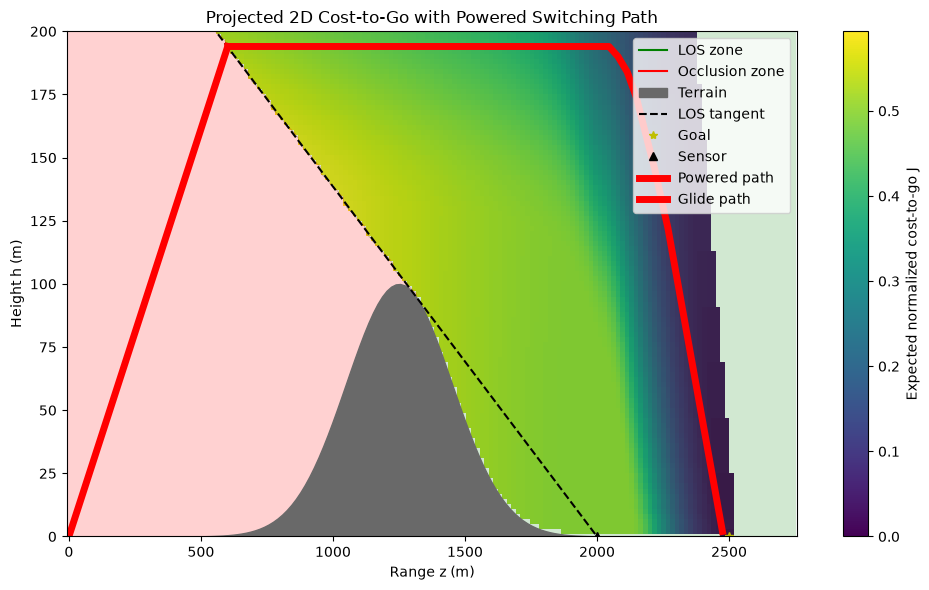

In [10]:
assert np.any(np.isfinite(CostToGo))
figure, axis = plt.subplots(figsize=config['visualization']['figure_size'])
cost_image = axis.pcolormesh(z_grid, h_grid, np.ma.masked_invalid(CostToGo).T, shading='auto', cmap=config['visualization']['cost_colormap'])
axis.contourf(grid_z, grid_h, occlusion_mask.astype(int), levels=[-0.5, 0.5, 1.5], colors=['green', 'red'], alpha=0.18)
axis.plot([], [], color='green', label='LOS zone'); axis.plot([], [], color='red', label='Occlusion zone')
axis.fill_between(terrain_z, terrain_h, color='dimgray', label='Terrain')
axis.plot(z_grid, tangent_slope*z_grid+tangent_intercept, 'k--', label='LOS tangent')
axis.plot(config['mission']['z_goal'], config['mission']['h_goal'], 'y*', label='Goal')
axis.plot(config['mission']['z_sensor'], config['mission']['h_sensor'], 'k^', label='Sensor')
axis.plot(powered_path[:, 0], powered_path[:, 1], color='red', linestyle='-', linewidth=5, label='Powered path')
axis.plot(optimal_glide_path[:, 0], optimal_glide_path[:, 1], color='red', linestyle='-', linewidth=5, label='Glide path')
axis.set(xlabel='Range z (m)', ylabel='Height h (m)', ylim=(config['grid']['h_min'], config['grid']['h_max']), title='Projected 2D Cost-to-Go with Powered Switching Path')
axis.legend(loc='upper right'); figure.colorbar(cost_image, ax=axis, label='Expected normalized cost-to-go J'); figure.tight_layout(); plt.show()


## 12. Sensor-Location Full-Replanning Extension

Stages 12 and 13 call the exact same common response solver as the fixed snapshot.  No LOS, Bellman, switching, or path logic is duplicated here.


### 12.0 Snapshot-equivalence regression test

The sensor wrapper is evaluated independently at the exact snapshot coordinate `(2000, 0)` and all scalar, map, policy, switch, and path outputs are compared.


In [ ]:
# Stage 12 uses only the common snapshot solver defined in Section 5.
sensor_sweep_config = deepcopy(sensor_evaluation_config)
sensor_sweep_config.update({
    'z_min':1500.0,'z_max':2400.0,'count':10,
    'coarse_z_count':81,'coarse_h_count':51,'fine_top_k':3,
})

def assert_common_response_equivalent(reference,candidate):
    """Regression test for the fixed snapshot and sensor wrapper at one coordinate."""
    assert reference['success']==candidate['success'] and reference['failure_reason']==candidate['failure_reason']
    scalar_keys=('z_sensor','h_sensor','tangent_z','tangent_h','tangent_slope','tangent_intercept',
                 'attacker_total_cost','switch_z','switch_h','policy_mission_pod','mission_pod',
                 'mission_detection_hazard','defender_utility')
    for key in scalar_keys:
        assert np.isclose(reference[key],candidate[key],rtol=1e-11,atol=1e-12),key
    array_keys=('J4D','StagePoD4D','ProjectedCost','CostToGo','PoDToGo','TimeToGo',
                'PolicySpeed','PolicyGamma','NextIndexZ','NextIndexH','los_mask','occlusion_mask',
                'powered_path','glide_path')
    for key in array_keys:
        left,right=np.asarray(reference[key]),np.asarray(candidate[key])
        if left.dtype.kind in 'biu' and right.dtype.kind in 'biu':
            assert np.array_equal(left,right),key
        else:
            assert np.allclose(left,right,rtol=1e-11,atol=1e-12,equal_nan=True),key

snapshot_result_via_sensor_wrapper=solve_attacker_response_for_sensor(
    2000.0,snapshot_planner_config,sensor_sweep_config,h_sensor_override=0.0,
    return_full_maps=True,use_cache=False,verbose=False)
assert_common_response_equivalent(snapshot_result,snapshot_result_via_sensor_wrapper)
print('PASS: snapshot_result(2000,0) == solve_attacker_response_for_sensor(2000,0)')


### 12.1 Two-stage coarse-to-fine sensor search

The planning-grid resolution changes between the two fidelity levels, but both levels execute the same common solver.


In [ ]:
# Two-stage search changes grid resolution for speed, but never changes solver logic.
coarse_sensor_config=make_planner_configuration(config,sensor_sweep_config['coarse_z_count'],sensor_sweep_config['coarse_h_count'])
fine_sensor_config=snapshot_planner_config
z_sensor_candidates=np.linspace(sensor_sweep_config['z_min'],sensor_sweep_config['z_max'],sensor_sweep_config['count'])
coarse_sensor_sweep_results=[]; coarse_started=time.perf_counter()
for number,z_candidate in enumerate(z_sensor_candidates,1):
    started=time.perf_counter()
    result=solve_attacker_response_for_sensor(z_candidate,coarse_sensor_config,sensor_sweep_config,verbose=False)
    result['fidelity']='coarse'; result['runtime_s']=time.perf_counter()-started
    coarse_sensor_sweep_results.append(result)
    print(f"coarse [{number}/{len(z_sensor_candidates)}] z={z_candidate:.1f} success={result['success']} "
          f"reason={result.get('failure_reason')} U_D={result.get('defender_utility',np.nan):.6g} runtime={result['runtime_s']:.1f}s")
coarse_success=[item for item in coarse_sensor_sweep_results if item['success']]
if not coarse_success:
    raise RuntimeError('No successful coarse sensor responses: '+str([(r['z_sensor'],r['failure_reason']) for r in coarse_sensor_sweep_results]))
top_coarse=sorted(coarse_success,key=lambda item:item['defender_utility'],reverse=True)[:sensor_sweep_config['fine_top_k']]
fine_sensor_sweep_results=[]; fine_started=time.perf_counter()
for number,coarse_result in enumerate(top_coarse,1):
    started=time.perf_counter()
    result=solve_attacker_response_for_sensor(coarse_result['z_sensor'],fine_sensor_config,sensor_sweep_config,
                                               return_full_maps=True,verbose=False)
    result['fidelity']='fine'; result['coarse_defender_utility']=coarse_result['defender_utility']
    result['runtime_s']=time.perf_counter()-started; fine_sensor_sweep_results.append(result)
    print(f"fine [{number}/{len(top_coarse)}] z={result['z_sensor']:.1f} success={result['success']} "
          f"reason={result.get('failure_reason')} U_D={result.get('defender_utility',np.nan):.6g} runtime={result['runtime_s']:.1f}s")
successful_sensor_results=[item for item in fine_sensor_sweep_results if item['success']]
if not successful_sensor_results:
    raise RuntimeError('No successful fine responses: '+str([(r['z_sensor'],r['failure_reason']) for r in fine_sensor_sweep_results]))
sensor_sweep_results=fine_sensor_sweep_results
best_sensor_result=max(successful_sensor_results,key=lambda item:item['defender_utility'])
best_sensor_full_result=best_sensor_result
terrain_following_baseline=solve_attacker_response_for_sensor(2000.0,fine_sensor_config,sensor_sweep_config)
print(f'Coarse runtime={time.perf_counter()-coarse_started:.1f}s; fine runtime={time.perf_counter()-fine_started:.1f}s')
print('Selected fine sensor:',best_sensor_result['z_sensor'],best_sensor_result['h_sensor'],best_sensor_result['defender_utility'])


### 12.2 Sweep results and full-grid best response


In [ ]:
failure_counts={}
for result in coarse_sensor_sweep_results+fine_sensor_sweep_results:
    if not result['success']:
        failure_counts[result['failure_reason']]=failure_counts.get(result['failure_reason'],0)+1
print('Failure summary:',failure_counts)
coarse_ok=[item for item in coarse_sensor_sweep_results if item['success']]
figure,axis=plt.subplots(figsize=config['visualization']['figure_size'])
axis.plot([r['z_sensor'] for r in coarse_ok],[r['defender_utility'] for r in coarse_ok],'o-',label='Coarse-grid response')
axis.scatter([r['z_sensor'] for r in successful_sensor_results],[r['defender_utility'] for r in successful_sensor_results],
             marker='*',s=130,label='Full-grid top candidates')
axis.set(xlabel='Sensor z position',ylabel='Defender utility'); axis.legend(); figure.tight_layout(); plt.show()
best=best_sensor_full_result
figure,axis=plt.subplots(figsize=config['visualization']['figure_size'])
image=axis.pcolormesh(best['z_grid'],best['h_grid'],np.ma.masked_invalid(best['CostToGo']).T,
                      shading='auto',cmap=config['visualization']['cost_colormap'])
axis.contourf(best['grid_z'],best['grid_h'],best['occlusion_mask'].astype(int),levels=[-.5,.5,1.5],
              colors=['green','red'],alpha=.18)
axis.plot(terrain_z,terrain_h,'k-',label='Terrain')
axis.plot(best['z_grid'],best['tangent_slope']*best['z_grid']+best['tangent_intercept'],'k--',label='LOS tangent')
axis.plot(best['z_sensor'],best['h_sensor'],'k^',label='Best sensor')
axis.plot(best['powered_path'][:,0],best['powered_path'][:,1],'r--',label='Powered path')
axis.plot(best['glide_path'][:,0],best['glide_path'][:,1],'r-',label='Glide path')
axis.set_title(f"Best sensor z={best['z_sensor']:.1f}, U_D={best['defender_utility']:.3f}, J={best['attacker_total_cost']:.3f}")
axis.legend(); figure.colorbar(image,ax=axis,label='Expected normalized cost-to-go J'); figure.tight_layout(); plt.show()
for result in successful_sensor_results:
    assert 0.0<=result['mission_pod']<=1.0 and 0.0<=result['normalized_los_area']<=1.0
    assert result['switch_diagnostics']['accepted_switch_candidates']>0
    assert np.all(np.diff(result['glide_path'][:,0])>0.0)


## 13. Stackelberg Response-Landscape and Gradient Validity

Unlike Stage 12, every Stage 13 evaluation uses one fixed planning grid.  Only the sensor-position sampling interval changes, so the finite-difference test does not mix grid-resolution changes with the response landscape.


In [ ]:
# Stage 13 diagnoses U_D(z_sensor) with one fixed planning grid at every location.
# Set run=True only when intentionally running the expensive landscape diagnostic.
stackelberg_diagnostic_config={
    'run':False,'z_min':1500.0,'z_max':2400.0,'coarse_sensor_count':41,
    'planning_z_count':len(z_grid),'planning_h_count':len(h_grid),
    'fine_neighborhood_half_width_m':50.0,'fine_spacing_m':5.0,
    'max_fine_centers':3,'switch_jump_threshold_m':100.0,
}
print('Stage 13 disabled. Set stackelberg_diagnostic_config["run"] = True to execute.')


### 13.1 Fixed-grid response-landscape evaluation


In [ ]:
if stackelberg_diagnostic_config['run']:
    diagnostic_planner_config=make_planner_configuration(
        config,stackelberg_diagnostic_config['planning_z_count'],stackelberg_diagnostic_config['planning_h_count'])
    diagnostic_z=np.linspace(stackelberg_diagnostic_config['z_min'],stackelberg_diagnostic_config['z_max'],
                             stackelberg_diagnostic_config['coarse_sensor_count'])
    stackelberg_landscape_coarse=[]; started=time.perf_counter()
    for number,z_candidate in enumerate(diagnostic_z,1):
        result=solve_attacker_response_for_sensor(z_candidate,diagnostic_planner_config,sensor_evaluation_config)
        stackelberg_landscape_coarse.append(result)
        print(f"[coarse {number}/{len(diagnostic_z)}] z={z_candidate:.1f} success={result['success']} "
              f"reason={result.get('failure_reason')} U_D={result.get('defender_utility',np.nan):.6g}")
    coarse_success=np.array([r['success'] for r in stackelberg_landscape_coarse],dtype=bool)
    coarse_utility=np.array([r.get('defender_utility',np.nan) for r in stackelberg_landscape_coarse])
    coarse_switch_z=np.array([r.get('switch_z',np.nan) for r in stackelberg_landscape_coarse])
    gradient_table={}; base_dz=float(diagnostic_z[1]-diagnostic_z[0])
    for multiplier in (1,2,4):
        derivative=np.full(diagnostic_z.size,np.nan)
        for i in range(multiplier,diagnostic_z.size-multiplier):
            if coarse_success[i-multiplier] and coarse_success[i+multiplier]:
                derivative[i]=(coarse_utility[i+multiplier]-coarse_utility[i-multiplier])/(2*multiplier*base_dz)
        gradient_table[multiplier]=derivative
    local_maxima=[]; policy_jumps=[]; feasibility_boundaries=[]
    for i in range(1,diagnostic_z.size-1):
        if coarse_success[i] and coarse_success[i-1] and coarse_success[i+1] and coarse_utility[i]>=coarse_utility[i-1] and coarse_utility[i]>=coarse_utility[i+1]:
            local_maxima.append(i)
        if coarse_success[i] and coarse_success[i-1] and abs(coarse_switch_z[i]-coarse_switch_z[i-1])>stackelberg_diagnostic_config['switch_jump_threshold_m']:
            policy_jumps.append(i)
        if coarse_success[i]!=coarse_success[i-1]:
            feasibility_boundaries.append(i)
    valid=np.flatnonzero(coarse_success & np.isfinite(coarse_utility))
    ranked=list(valid[np.argsort(coarse_utility[valid])[::-1]]) if valid.size else []
    center_indices=list(dict.fromkeys(ranked[:3]+local_maxima+policy_jumps+feasibility_boundaries))[:stackelberg_diagnostic_config['max_fine_centers']]
    fine_positions=[]; half=stackelberg_diagnostic_config['fine_neighborhood_half_width_m']; spacing=stackelberg_diagnostic_config['fine_spacing_m']
    for index in center_indices:
        fine_positions.extend(np.arange(diagnostic_z[index]-half,diagnostic_z[index]+half+0.5*spacing,spacing))
    fine_positions=np.array(sorted({round(float(z),8) for z in fine_positions
                                    if diagnostic_z[0]<=z<=diagnostic_z[-1]}))
    stackelberg_landscape_fine=[]
    for number,z_candidate in enumerate(fine_positions,1):
        # Same diagnostic_planner_config as the coarse sensor-position pass.
        result=solve_attacker_response_for_sensor(z_candidate,diagnostic_planner_config,sensor_evaluation_config)
        stackelberg_landscape_fine.append(result)
        print(f"[fine {number}/{len(fine_positions)}] z={z_candidate:.1f} success={result['success']} "
              f"reason={result.get('failure_reason')} U_D={result.get('defender_utility',np.nan):.6g}")
    stackelberg_landscape={'coarse_z':diagnostic_z,'coarse_results':stackelberg_landscape_coarse,
        'coarse_success':coarse_success,'coarse_utility':coarse_utility,'coarse_switch_z':coarse_switch_z,
        'gradient_table':gradient_table,'local_maxima_indices':np.array(local_maxima,dtype=int),
        'policy_jump_indices':np.array(policy_jumps,dtype=int),
        'feasibility_boundary_indices':np.array(feasibility_boundaries,dtype=int),
        'fine_positions':fine_positions,'fine_results':stackelberg_landscape_fine,
        'planning_grid_shape':(len(diagnostic_planner_config['grid']['z']),len(diagnostic_planner_config['grid']['h']))}
    print(f"Stage 13.1 complete in {time.perf_counter()-started:.1f}s using fixed planning grid {stackelberg_landscape['planning_grid_shape']}")
else:
    stackelberg_landscape=None


### 13.2 Gradient, policy-jump, and feasibility diagnostics


In [ ]:
if stackelberg_landscape is not None:
    landscape=stackelberg_landscape
    fig,axes=plt.subplots(3,1,figsize=(11,11),sharex=True,constrained_layout=True)
    axes[0].plot(landscape['coarse_z'],landscape['coarse_utility'],'o-',label='coarse sensor positions')
    fine_success=[r for r in landscape['fine_results'] if r['success']]
    if fine_success:
        axes[0].plot([r['z_sensor'] for r in fine_success],[r['defender_utility'] for r in fine_success],'r.',ms=8,label='fine sensor positions')
    for index in landscape['policy_jump_indices']:
        axes[0].axvline(landscape['coarse_z'][index],color='tab:orange',alpha=.4)
    for index in landscape['feasibility_boundary_indices']:
        axes[0].axvline(landscape['coarse_z'][index],color='k',ls='--',alpha=.35)
    axes[0].set_ylabel('Defender utility $U_D$'); axes[0].legend()
    for multiplier,derivative in landscape['gradient_table'].items():
        axes[1].plot(landscape['coarse_z'],derivative,'o-',label=fr'$\Delta z={multiplier}dz$')
    axes[1].axhline(0,color='k',lw=.8); axes[1].set_ylabel(r'$dU_D/dz_{sensor}$'); axes[1].legend()
    axes[2].plot(landscape['coarse_z'],landscape['coarse_switch_z'],'o-')
    axes[2].set(xlabel=r'Sensor position $z_{sensor}$',ylabel=r'Switch position $z_{switch}$')
    plt.show()
    stable=(np.isfinite(landscape['gradient_table'][1])&np.isfinite(landscape['gradient_table'][2])
            &(np.sign(landscape['gradient_table'][1])==np.sign(landscape['gradient_table'][2])))
    print('Gradient-sign-consistent samples:',int(stable.sum()),'/',int(np.isfinite(landscape['gradient_table'][1]).sum()))
    print('Policy jumps:',landscape['coarse_z'][landscape['policy_jump_indices']])
    print('Feasibility boundaries:',landscape['coarse_z'][landscape['feasibility_boundary_indices']])
    failure_summary={}
    for result in landscape['coarse_results']+landscape['fine_results']:
        if not result['success']:
            failure_summary[result['failure_reason']]=failure_summary.get(result['failure_reason'],0)+1
    print('Failure summary:',failure_summary)
